### Loading and Preprocessing MNIST

Load the MNIST training dataset using `torchvision.datasets`.  
Each 28×28 image is converted to a tensor, normalized to `[0,1]`, and flattened into a 784-length vector for model input.

In [50]:
import torch
from torch.utils.data import random_split
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

full_dataset = datasets.MNIST(root='../ML2_Data', train=True, transform=transform, download=True)

### Creating a Binary Dataset for Logistic Regression Model (Digits 0 and 1)

Select only samples labeled **0** and **1** from the full MNIST dataset  
to create a smaller binary classification dataset, which will be used  
for training a logistic regression model.


In [51]:
from torch.utils.data import Subset

# Filter indices for digits 0 and 1 to new dataset
indices_01 = [i for i, (_, y) in enumerate(full_dataset) if y in (0, 1)]
binary_dataset = Subset(full_dataset, indices_01)

print(f"Full dataset size: {len(full_dataset)}")
print(f"Binary dataset (0 and 1) size: {len(binary_dataset)}")

Full dataset size: 60000
Binary dataset (0 and 1) size: 12665


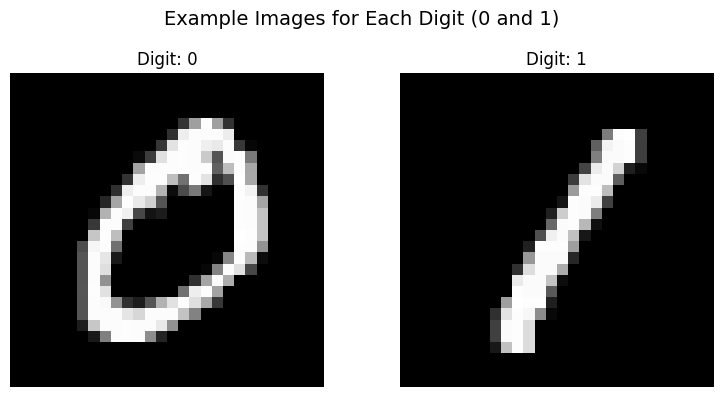

In [52]:
import matplotlib.pyplot as plt

# Store one example image for each digit 
examples = {}
for img, label in binary_dataset:
    if label not in examples: 
        examples[label] = img
    if len(examples) == 2: 
        break

# Plotting
plt.figure(figsize=(8, 4))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(examples[i].view(28, 28), cmap='gray')  # reshape to 28*28 image
    plt.title(f"Digit: {i}")
    plt.axis('off')

plt.suptitle("Example Images for Each Digit (0 and 1)", fontsize=14)
plt.subplots_adjust(top=0.8) 
plt.tight_layout()
plt.show()


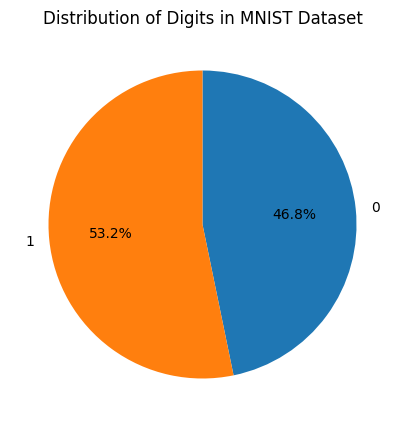

In [53]:

# Get labels
labels = [label for _, label in binary_dataset]

# Count how many times each label appears
unique_labels, counts = torch.unique(torch.tensor(labels), return_counts=True)

# Plotting
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=unique_labels.tolist(), autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Distribution of Digits in MNIST Dataset")
plt.show()

In [54]:
# Split binary dataset into 60% train, 20% val, 20% test
train_size = int(0.6 * len(binary_dataset))
val_size   = int(0.2 * len(binary_dataset))
test_size  = len(binary_dataset) - train_size - val_size

train_dataset_bin, val_dataset_bin, test_dataset_bin = torch.utils.data.random_split(
    binary_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42) 
)

# Get one sample to inspect
x_sample, y_sample = binary_dataset[0]
feature_dim = x_sample.numel()

# Print dataset information
print("Binary Dataset Summary\n")
print(f"Total samples:        {len(binary_dataset)}")
print(f"Training samples:     {len(train_dataset_bin)}")
print(f"Validation samples:   {len(val_dataset_bin)}")
print(f"Test samples:         {len(test_dataset_bin)}")
print(f"Feature dimension:    {feature_dim}")
print(f"Sample tensor shape:  {tuple(x_sample.shape)}")
print(f"Example label:        {y_sample}")


Binary Dataset Summary

Total samples:        12665
Training samples:     7599
Validation samples:   2533
Test samples:         2533
Feature dimension:    784
Sample tensor shape:  (784,)
Example label:        0


In [55]:
from torch.utils.data import DataLoader

# Create DataLoaders for binary classification
train_loader_bin = DataLoader(train_dataset_bin, batch_size=64, shuffle=True)
val_loader_bin   = DataLoader(val_dataset_bin, batch_size=64, shuffle=False)
test_loader_bin  = DataLoader(test_dataset_bin, batch_size=64, shuffle=False)

print("DataLoaders created successfully\n")
print("Batch size: 64")
print(f"No. of rain batches: {len(train_loader_bin)}")
print(f"No. of validation batches: {len(val_loader_bin)}")
print(f"No. of test batches: {len(test_loader_bin)}")


DataLoaders created successfully

Batch size: 64
No. of rain batches: 119
No. of validation batches: 40
No. of test batches: 40


In [56]:

W = torch.randn(28*28, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

def model(X):
    return sigmoid(X @ W + b)

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -torch.mean(y_true * torch.log(y_pred+eps) + (1-y_true) * torch.log(1-y_pred+eps))


In [57]:
learning_rate = 0.01
epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    total_train_loss, correct_train, total_train = 0, 0, 0

    for X_batch, y_batch in train_loader_bin:
        y_true = y_batch.float().view(-1, 1)
        y_pred = model(X_batch)
        loss = binary_cross_entropy(y_pred, y_true)

        # Gradient Descent
        loss.backward()
        with torch.no_grad():
            W -= learning_rate * W.grad
            b -= learning_rate * b.grad
        W.grad.zero_()
        b.grad.zero_()

        predictions = (y_pred > 0.5).float()
        correct_train += (predictions == y_true).sum().item()
        total_train += y_true.size(0)
        total_train_loss += loss.item() * y_true.size(0)

    train_loss = total_train_loss / total_train
    train_acc = 100 * correct_train / total_train

    # Validation 
    total_val_loss, correct_val, total_val = 0, 0, 0

    with torch.no_grad():  # no gradients for validation
        for X_val, y_val in val_loader_bin:
            y_true = y_val.float().view(-1, 1)
            y_pred = model(X_val)
            loss = binary_cross_entropy(y_pred, y_true)

            predictions = (y_pred > 0.5).float()
            correct_val += (predictions == y_true).sum().item()
            total_val += y_true.size(0)
            total_val_loss += loss.item() * y_true.size(0)

    val_loss = total_val_loss / total_val
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


Epoch 1/20 | Train Loss: 1.0432, Train Acc: 68.42% | Val Loss: 0.5470, Val Acc: 82.55%
Epoch 2/20 | Train Loss: 0.3963, Train Acc: 87.27% | Val Loss: 0.3041, Val Acc: 90.45%
Epoch 3/20 | Train Loss: 0.2455, Train Acc: 92.51% | Val Loss: 0.2173, Val Acc: 93.53%
Epoch 4/20 | Train Loss: 0.1832, Train Acc: 94.47% | Val Loss: 0.1731, Val Acc: 94.95%
Epoch 5/20 | Train Loss: 0.1491, Train Acc: 95.59% | Val Loss: 0.1463, Val Acc: 95.85%
Epoch 6/20 | Train Loss: 0.1276, Train Acc: 96.30% | Val Loss: 0.1282, Val Acc: 96.53%
Epoch 7/20 | Train Loss: 0.1126, Train Acc: 96.67% | Val Loss: 0.1151, Val Acc: 96.92%
Epoch 8/20 | Train Loss: 0.1016, Train Acc: 97.13% | Val Loss: 0.1052, Val Acc: 97.32%
Epoch 9/20 | Train Loss: 0.0931, Train Acc: 97.39% | Val Loss: 0.0975, Val Acc: 97.55%
Epoch 10/20 | Train Loss: 0.0863, Train Acc: 97.59% | Val Loss: 0.0912, Val Acc: 97.71%
Epoch 11/20 | Train Loss: 0.0808, Train Acc: 97.72% | Val Loss: 0.0861, Val Acc: 97.83%
Epoch 12/20 | Train Loss: 0.0761, Train A

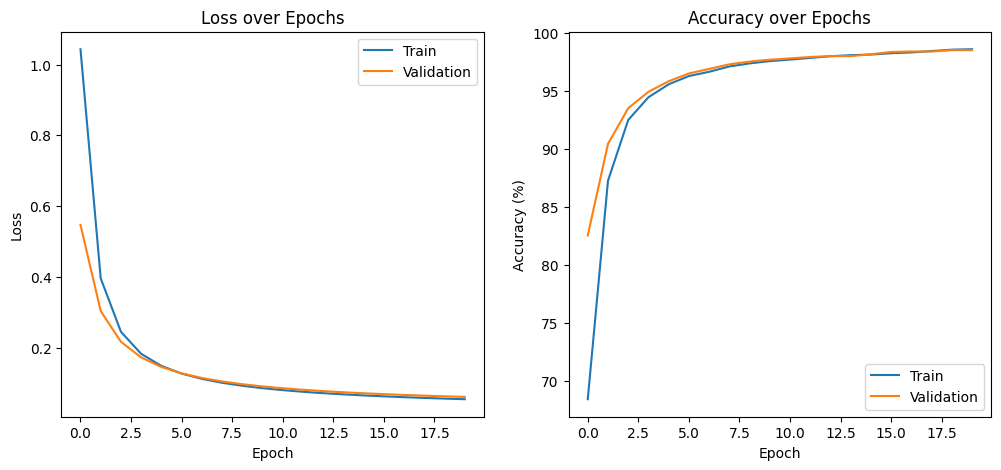

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train')
plt.plot(val_accuracies, label='Validation')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()



In [59]:

total_test_loss, correct_test, total_test = 0, 0, 0

with torch.no_grad():
    for X_test, y_test in test_loader_bin:
        y_true = y_test.float().view(-1, 1)
        y_pred = model(X_test)
        loss = binary_cross_entropy(y_pred, y_true)

        predictions = (y_pred > 0.5).float()
        correct_test += (predictions == y_true).sum().item()
        total_test += y_true.size(0)
        total_test_loss += loss.item() * y_true.size(0)

test_loss = total_test_loss / total_test
test_acc = 100 * correct_test / total_test

print("\n=== Final Test Evaluation ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")



=== Final Test Evaluation ===
Test Loss: 0.0382
Test Accuracy: 98.70%


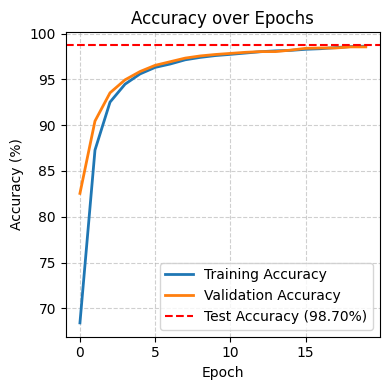

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))  # smaller square (4x4 inches)

plt.plot(train_accuracies, label='Training Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2)
plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Accuracy ({test_acc:.2f}%)')

plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Softmax

In [60]:
train_size = int(0.6 * len(full_dataset))
val_size   = int(0.2 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Get one sample to inspect dimensions
x_sample, y_sample = full_dataset[0]
feature_dim = x_sample.numel()

print("Dataset Summary\n")

print(f"Total samples:        {len(full_dataset)}")
print(f"Training samples:     {len(train_dataset)}")
print(f"Validation samples:   {len(val_dataset)}")
print(f"Test samples:         {len(test_dataset)}")
print(f"Feature dimension:    {feature_dim}")
print(f"Sample tensor shape: {tuple(x_sample.shape)}")
print(f"Example label:        {y_sample}")


Dataset Summary

Total samples:        60000
Training samples:     36000
Validation samples:   12000
Test samples:         12000
Feature dimension:    784
Sample tensor shape: (784,)
Example label:        5


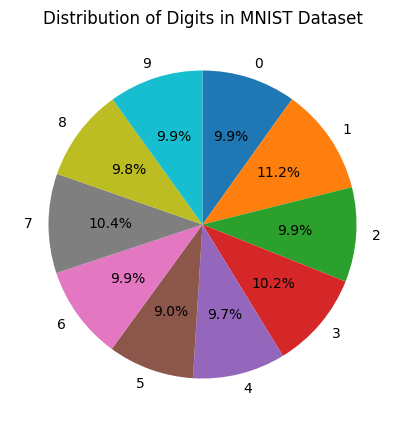

In [61]:
# Get all labels
labels = [label for _, label in full_dataset]

# Count how many times each label appears
unique_labels, counts = torch.unique(torch.tensor(labels), return_counts=True)

# Plotting
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=unique_labels.tolist(), autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Distribution of Digits in MNIST Dataset")
plt.show()

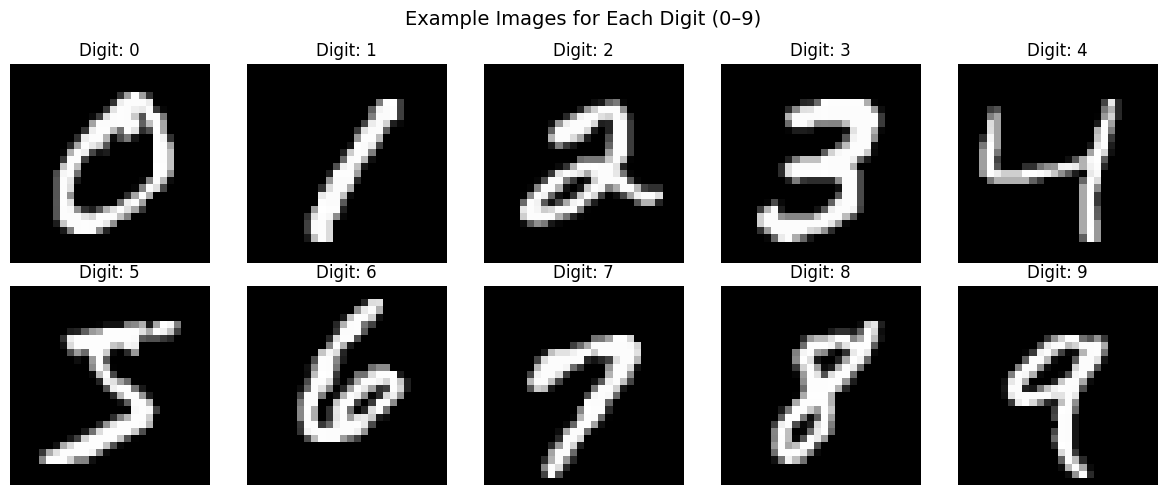

In [62]:
# Store one example image for each digit 
examples = {}
for img, label in full_dataset:
    if label not in examples: 
        examples[label] = img
    if len(examples) == 10: 
        break

# Plotting
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i].view(28, 28), cmap='gray')  # reshape to 28*28 image
    plt.title(f"Digit: {i}")
    plt.axis('off')

plt.suptitle("Example Images for Each Digit (0–9)", fontsize=14)
plt.tight_layout()
plt.show()

In [63]:

# Create DataLoaders for full 10-class (Softmax) classification
train_loader_full = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_full   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader_full  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders for Full Dataset (Softmax Regression)\n")
print("Batch size: 64")
print(f"No. of training batches:   {len(train_loader_full)}")
print(f"No. of validation batches: {len(val_loader_full)}")
print(f"No. of test batches:       {len(test_loader_full)}")


DataLoaders for Full Dataset (Softmax Regression)

Batch size: 64
No. of training batches:   563
No. of validation batches: 188
No. of test batches:       188
